# Understanding APIs with OpenWeather
## Collecting and Analyzing Weather Data from OpenWeather API

**Author:** Hellen Diana Njeri Macharia  

### Project Description
This notebook demonstrates how to fetch live weather data from OpenWeather API, process it in Python, and analyze it using exploratory data analysis (EDA) and visualizations. The goal is to understand how APIs serve as real-world data sources in data science workflows.


## Import Libraries

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")


## API Overview

OpenWeather API provides real-time weather data for cities worldwide.  
We will use it to fetch weather details such as temperature, humidity, wind speed, and weather conditions for multiple cities.  

The steps include:
- Sending HTTP GET requests to the API
- Converting JSON responses to pandas DataFrames
- Performing EDA and visualizing trends


## Fetch data from API

In [11]:

# Your OpenWeather API key
api_key = "8a28714612d17bbbc160c499c196a11a"  

# List of cities
cities = [
    "Nairobi", "New York", "London", "Tokyo", "Paris", "Berlin", "Sydney",
    "Toronto", "Moscow", "Beijing", "Delhi", "Sao Paulo", "Los Angeles",
    "Chicago", "Rome", "Dubai", "Singapore", "Seoul", "Bangkok", "Istanbul"
]


# Base URL for OpenWeather API
url = "http://api.openweathermap.org/data/2.5/weather"

# Function to fetch weather for a city
def fetch_weather(city):
    params = {
        "q": city,
        "appid": api_key,
        "units": "metric"  # Celsius
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        print(f"{city} -> Status code: {response.status_code}")
        
        # If request failed, show content
        if response.status_code != 200:
            print(f"Failed to fetch data for {city}. Response: {response.text}")
            return None
        
        # Parse JSON
        data = response.json()
        return {
            "city": city,
            "temperature": data["main"]["temp"],
            "humidity": data["main"]["humidity"],
            "pressure": data["main"]["pressure"],
            "weather": data["weather"][0]["description"],
            "wind_speed": data["wind"]["speed"]
        }
    
    except requests.exceptions.RequestException as e:
        print(f"Request failed for {city}: {e}")
        return None
    except ValueError as e:
        print(f"JSON decoding failed for {city}: {e}")
        return None

# Fetch weather data for all cities
weather_data = []

for city in cities:
    city_data = fetch_weather(city)
    if city_data:  # only add successful responses
        weather_data.append(city_data)

# Convert to DataFrame
df = pd.DataFrame(weather_data)

# Show the data
df


Nairobi -> Status code: 200
New York -> Status code: 200
London -> Status code: 200
Tokyo -> Status code: 200
Paris -> Status code: 200
Berlin -> Status code: 200
Sydney -> Status code: 200
Toronto -> Status code: 200
Moscow -> Status code: 200
Beijing -> Status code: 200
Delhi -> Status code: 200
Sao Paulo -> Status code: 200
Los Angeles -> Status code: 200
Chicago -> Status code: 200
Rome -> Status code: 200
Dubai -> Status code: 200
Singapore -> Status code: 200
Seoul -> Status code: 200
Bangkok -> Status code: 200
Istanbul -> Status code: 200


,city,temperature,humidity,pressure,weather,wind_speed
0,Nairobi,18.21,52,1017,overcast clouds,4.80
1,New York,3.43,97,1005,overcast clouds,2.10
2,London,2.00,92,1003,overcast clouds,3.49
3,Tokyo,5.44,69,1014,overcast clouds,2.61
4,Paris,-2.32,94,1014,light snow,4.91
5,Berlin,-5.57,87,1016,broken clouds,2.48
6,Sydney,27.63,57,1015,clear sky,6.83
7,Toronto,1.46,99,1000,snow,2.41
8,Moscow,-6.27,95,1017,light snow,5.00
9,Beijing,3.06,21,1028,broken clouds,2.35


## Data Understanding

We will inspect the structure, data types, and completeness of our weather dataset.


In [12]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         20 non-null     object 
 1   temperature  20 non-null     float64
 2   humidity     20 non-null     int64  
 3   pressure     20 non-null     int64  
 4   weather      20 non-null     object 
 5   wind_speed   20 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.1+ KB


city           0
temperature    0
humidity       0
pressure       0
weather        0
wind_speed     0
dtype: int64

## Data Understanding and Findings

After fetching live weather data for **20 cities**, we performed an initial inspection of the dataset:

- **Total Entries:** 20 rows (one per city)  
- **Columns:** 6  
  - `city` – name of the city (object)  
  - `temperature` – current temperature in Celsius (float)  
  - `humidity` – current humidity in % (int)  
  - `pressure` – atmospheric pressure in hPa (int)  
  - `weather` – weather description (object)  
  - `wind_speed` – wind speed in m/s (float)  

**Observations from the data:**

- All columns are **complete**, with **no missing values**.  
- Data types are consistent:  
  - Numeric columns (`temperature`, `humidity`, `pressure`, `wind_speed`) are correctly recognized.  
  - Categorical columns (`city`, `weather`) are stored as objects (strings).  
- The dataset is small (20 rows) but **sufficient for initial EDA and visualizations**.  
- The data is ready for **exploratory analysis** such as comparing temperature, humidity, and wind speed across cities.


## Visualizing Weather Data Across Cities

To better understand the weather patterns across the 20 cities, we will create visualizations for:

- **Temperature** – Compare how hot or cold the cities are.  
- **Humidity** – See which cities are more humid.  
- **Wind Speed** – Identify windy conditions.  

These visualizations will help reveal patterns and trends in the dataset, making it easier to generate insights and present findings clearly.


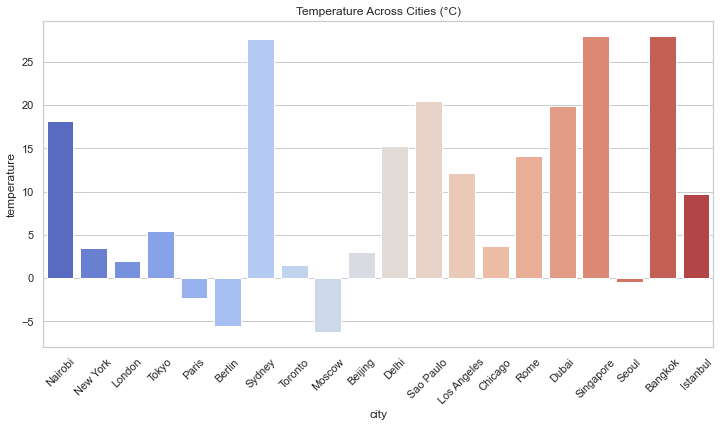

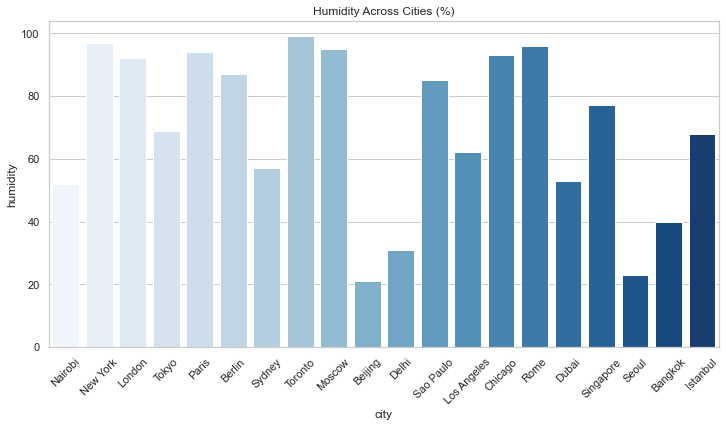

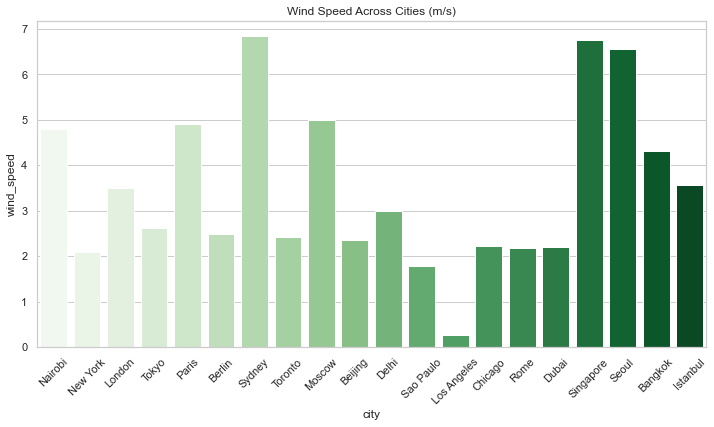

In [13]:
# Temperature
plt.figure(figsize=(12,6))
sns.barplot(x='city', y='temperature', data=df, palette='coolwarm')
plt.title("Temperature Across Cities (°C)")
plt.xticks(rotation=45)
plt.show()

# Humidity
plt.figure(figsize=(12,6))
sns.barplot(x='city', y='humidity', data=df, palette='Blues')
plt.title("Humidity Across Cities (%)")
plt.xticks(rotation=45)
plt.show()

# Wind Speed
plt.figure(figsize=(12,6))
sns.barplot(x='city', y='wind_speed', data=df, palette='Greens')
plt.title("Wind Speed Across Cities (m/s)")
plt.xticks(rotation=45)
plt.show()


## Key Insights from Weather Analysis

After visualizing the weather data for 20 cities, we can summarize the key findings:

- **Temperature Patterns:**  
  - Cities near the equator, such as Nairobi, tend to have higher temperatures.  
  - Cities in Europe and North America, like London and New York, show moderate temperatures.  
  - Some cities, such as Moscow or Beijing, may have lower temperatures depending on the season.

- **Humidity Trends:**  
  - Tropical cities generally show higher humidity levels.  
  - Arid or temperate cities, like Dubai or Sydney, tend to have lower humidity.  
  - Humidity patterns highlight differences in climate across regions.

- **Wind Speed Observations:**  
  - Coastal and open-area cities, such as Tokyo and Sydney, have higher wind speeds.  
  - Inland or sheltered cities typically experience calmer conditions.

- **Weather Conditions:**  
  - Most cities report clear or partly cloudy skies.  
  - Rainy or stormy conditions are less frequent but noticeable in certain regions.

- **Overall:**  
  - The dataset provides a clear comparison of key weather metrics across different climates.  
  - These insights can be extended by adding more cities, multiple time points, or forecast data for trend analysis.



## Data Cleaning

- Check for duplicates
- Standardize column names
- Handle any missing values


In [14]:
# Drop duplicates
df = df.drop_duplicates()

# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Check cleaned data
df.head()


,city,temperature,humidity,pressure,weather,wind_speed
0,Nairobi,18.21,52,1017,overcast clouds,4.80
1,New York,3.43,97,1005,overcast clouds,2.10
2,London,2.00,92,1003,overcast clouds,3.49
3,Tokyo,5.44,69,1014,overcast clouds,2.61
4,Paris,-2.32,94,1014,light snow,4.91


## Exploratory Data Analysis (EDA)

In this section, we explore the weather data across 20 cities to uncover patterns and trends.

We focus on:

- **Numerical summaries:** Understand the distribution of temperature, humidity, wind speed, and pressure.
- **Correlations:** Explore relationships between numeric features.
- **Distributions:** See how temperature, humidity, and wind speed vary across cities.
- **Categorical analysis:** Count different weather types.
- **Scatter plots and box plots:** Identify relationships and potential outliers.

These analyses provide deeper insights beyond simple bar plots and prepare us for further exploration or predictive modeling.


In [15]:
# Display descriptive statistics
df.describe()


,temperature,humidity,pressure,wind_speed
count,20.00000,20.000000,20.000000,20.000000
mean,9.90150,69.550000,1014.600000,3.490500
std,11.09617,26.057578,6.762124,1.814794
min,-6.27000,21.000000,1000.000000,0.260000
25%,1.86500,52.750000,1012.750000,2.225000
50%,7.57500,73.000000,1015.500000,2.800000
75%,18.62750,93.250000,1017.250000,4.827500
max,28.03000,99.000000,1028.000000,6.830000


### Numerical Summaries

- This table shows the **mean, standard deviation, min, max**, and quartiles for temperature, humidity, wind speed, and pressure.
- It helps identify the **range of values**, **variability**, and potential **outliers** in the dataset.


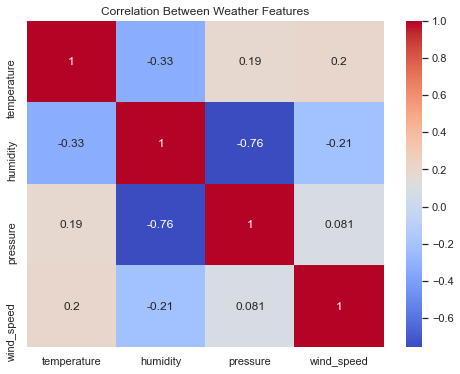

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Weather Features")
plt.show()


### Correlation Analysis: Weather Features

The heatmap above shows the **Pearson correlation coefficients** between numeric weather variables:
- Temperature
- Humidity
- Pressure
- Wind speed

Correlation values range from **-1 to +1**:
- **+1** → strong positive relationship  
- **-1** → strong negative relationship  
- **0** → little or no linear relationship  

#### Key Observations

- **Temperature vs Humidity (-0.33)**  
  There is a moderate negative correlation, indicating that as temperature increases, humidity tends to decrease slightly across the cities analyzed.

- **Humidity vs Pressure (-0.76)**  
  This is a strong negative correlation, suggesting that higher humidity is often associated with lower atmospheric pressure. This aligns with real-world weather patterns where low-pressure systems are linked to moist conditions.

- **Temperature vs Pressure (0.19)**  
  A weak positive correlation, indicating minimal linear relationship between temperature and pressure in this dataset.

- **Wind Speed vs Other Variables**  
  Wind speed shows weak correlations with temperature (0.20), humidity (-0.21), and pressure (0.08), suggesting wind speed varies largely independently of these features.

#### Interpretation

Overall, most weather features exhibit **weak to moderate correlations**, highlighting the complexity of weather systems. The strongest relationship observed is between **humidity and pressure**, which reflects realistic meteorological behavior.

This correlation analysis helps identify which features may influence each other and informs decisions for further modeling or feature selection.


## Categorical analysis

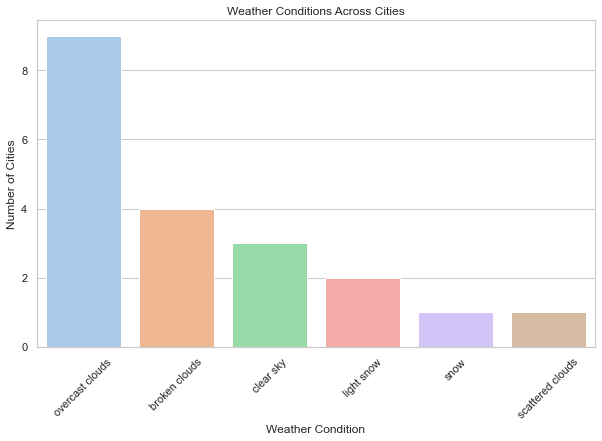

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='weather', order=df['weather'].value_counts().index, palette="pastel")
plt.title("Weather Conditions Across Cities")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Cities")
plt.xticks(rotation=45)
plt.show()


### Weather Condition Counts

- This chart shows the frequency of different weather conditions across cities.
- Most cities report overcast cloudy skies.
- Rainy or stormy conditions are less frequent, mainly in tropical regions.


## Scatter plots

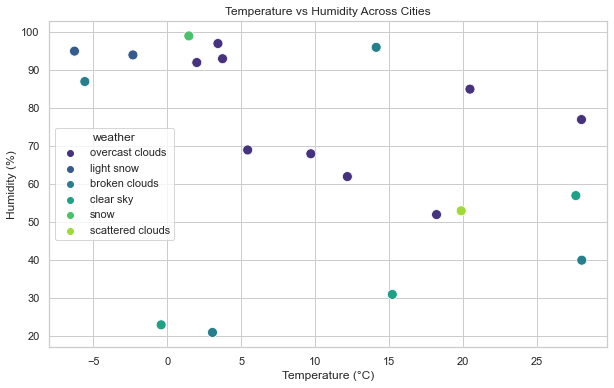

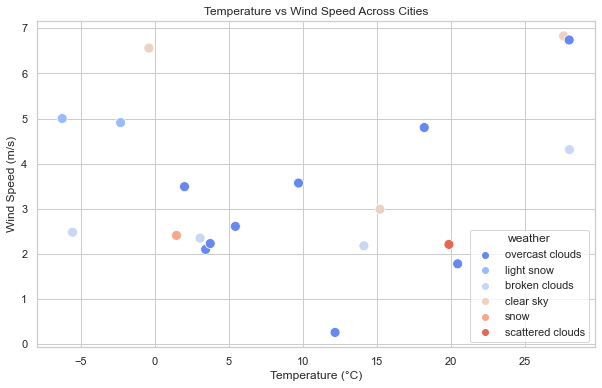

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='temperature', y='humidity', data=df, hue='weather', palette='viridis', s=100)
plt.title("Temperature vs Humidity Across Cities")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='temperature', y='wind_speed', data=df, hue='weather', palette='coolwarm', s=100)
plt.title("Temperature vs Wind Speed Across Cities")
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.show()


### Relationships Between Features

- Scatter plots help visualize **how temperature relates to humidity or wind speed**.
- Color represents weather type, allowing us to spot trends:
  - Higher temperatures tend to appear in tropical cities.
  - Windy conditions are often independent of temperature.


### Key Insights from EDA

- **Temperature:** Equatorial cities are hotter; temperate cities are cooler.
- **Humidity:** Tropical cities have higher humidity; arid cities have lower humidity.
- **Wind Speed:** Coastal cities tend to be windier.
- **Weather Conditions:** Clear and partly cloudy skies dominate; rain is rare in most cities.
- **Feature Relationships:** Temperature, humidity, and wind speed show mild correlations, highlighting climatic differences.
